In [3]:
import pandas as pd

# Load all datasets
cash_crops = pd.read_csv('FAOSTAT_data_en_6-15-2026.csv')
hunger = pd.read_csv('GHI.csv')
deaths = pd.read_csv('cause_of_deaths.csv')
child_mal = pd.read_csv('country-wise-average.csv')
adult_mal = pd.read_csv('2__Prevalence_of_Underweight_among_Female_Adults__Age_Standardized_Estimate_.csv')
gdp = pd.read_csv('3__GDP_per_capita__Constant_2015_US_.csv')
health_exp = pd.read_csv('4__Domestic_general_government_health_expenditure___of_GDP_.csv')

print("All datasets loaded!")
print(f"Cash Crops: {cash_crops.shape}")
print(f"Hunger Index: {hunger.shape}")
print(f"Deaths: {deaths.shape}")
print(f"Child Malnutrition: {child_mal.shape}")
print(f"Adult Malnutrition: {adult_mal.shape}")
print(f"GDP: {gdp.shape}")
print(f"Health Expenditure: {health_exp.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'country-wise-average.csv'

In [4]:
import os
files = os.listdir('/content/')
for f in files:
    if f.endswith('.csv'):
        print(f)

6. Mean-age-at-first-birth-of-women-aged-20-50-data.csv
1. Percentage-of-underweight-children-data.csv
4. Domestic general government health expenditure ( of GDP).csv
FAOSTAT_data_en_6-15-2026.csv
3. GDP per capita (Constant 2015 US).csv
5. Maternal Mortality Ratio.csv
cause_of_deaths.csv
GHI.csv
7. School enrollment secondary female ( gross).csv
2. Prevalence of Underweight among Female Adults (Age Standardized Estimate).csv


In [6]:
import pandas as pd

# Load all datasets
cash_crops = pd.read_csv('FAOSTAT_data_en_6-15-2026.csv')
hunger = pd.read_csv('GHI.csv')
deaths = pd.read_csv('cause_of_deaths.csv')
child_mal = pd.read_csv('1. Percentage-of-underweight-children-data.csv')
adult_mal = pd.read_csv('2. Prevalence of Underweight among Female Adults (Age Standardized Estimate).csv')
gdp = pd.read_csv('3. GDP per capita (Constant 2015 US).csv')
health_exp = pd.read_csv('4. Domestic general government health expenditure ( of GDP).csv')
maternal = pd.read_csv('5. Maternal Mortality Ratio.csv')

print("All datasets loaded!")
print(f"Cash Crops: {cash_crops.shape}")
print(f"Hunger Index: {hunger.shape}")
print(f"Deaths: {deaths.shape}")
print(f"Child Malnutrition: {child_mal.shape}")
print(f"Adult Malnutrition: {adult_mal.shape}")
print(f"GDP: {gdp.shape}")
print(f"Health Expenditure: {health_exp.shape}")
print(f"Maternal Mortality: {maternal.shape}")

All datasets loaded!
Cash Crops: (37610, 15)
Hunger Index: (125, 8)
Deaths: (6120, 34)
Child Malnutrition: (666, 5)
Adult Malnutrition: (1170, 4)
GDP: (1596, 4)
Health Expenditure: (1596, 4)
Maternal Mortality: (1596, 4)


In [11]:


# List of African countries
african_countries = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
    'Cameroon', 'Cape Verde', 'Central African Republic', 'Chad', 'Comoros',
    'Congo', 'Democratic Republic of Congo', "Cote d'Ivoire", 'Djibouti',
    'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia',
    'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya',
    'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali',
    'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger',
    'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone',
    'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo',
    'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
]

# Filter deaths dataset for Africa only
africa_deaths = deaths[deaths['Country/Territory'].isin(african_countries)]

# Filter GDP for Africa only
africa_gdp = gdp[gdp['Country Name'].isin(african_countries)]

# Filter cash crops for Africa only
africa_crops = cash_crops[cash_crops['Area'].isin(african_countries)]

print(f"African countries in deaths dataset: {africa_deaths['Country/Territory'].nunique()}")
print(f"African countries in GDP dataset: {africa_gdp['Country Name'].nunique()}")
print(f"African countries in crops dataset: {africa_crops['Area'].nunique()}")

African countries in deaths dataset: 53
African countries in GDP dataset: 48
African countries in crops dataset: 47


In [12]:
# Focus on key cash crops only
cash_crop_items = [
    'Cocoa beans', 'Coffee, green', 'Cotton lint, ginned',
    'Tea leaves', 'Unmanufactured tobacco', 'Sugar cane',
    'Palm oil', 'Groundnuts, shelled', 'Vanilla, raw'
]

# Filter for cash crops and export value only
africa_cash = africa_crops[
    (africa_crops['Item'].isin(cash_crop_items)) &
    (africa_crops['Element'] == 'Export value')
]

# Total export value per country across all years
top_exporters = africa_cash.groupby('Area')['Value'].sum().reset_index()
top_exporters.columns = ['Country', 'Total_Export_Value_USD']
top_exporters = top_exporters.sort_values('Total_Export_Value_USD', ascending=False).head(15)

print("Top 15 African Cash Crop Exporters:")
print(top_exporters)

Top 15 African Cash Crop Exporters:
         Country  Total_Export_Value_USD
19         Ghana              25612763.0
22         Kenya              21741665.0
46      Zimbabwe              14167547.0
16      Ethiopia              13833493.0
44        Uganda              12933293.0
6       Cameroon              11698757.0
35       Nigeria              10981250.0
27        Malawi               9883096.0
26    Madagascar               5839555.0
2          Benin               5735927.0
4   Burkina Faso               5180216.0
32    Mozambique               3917491.0
41         Sudan               3479650.0
12         Egypt               3262751.0
45        Zambia               2891270.0


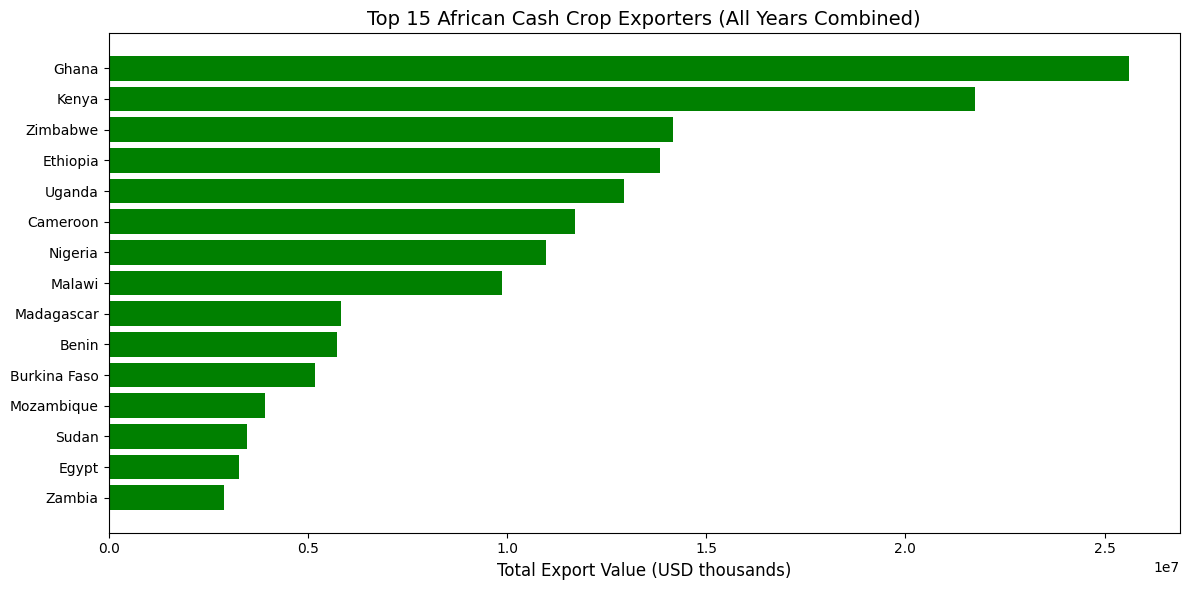


Hunger scores for top cash crop exporters:
     Country 2000 2008 2015 2023
       Egypt 16.4 16.9 15.2 12.8
       Ghana 28.5 22.2 15.7 13.7
    Cameroon   36   29 20.7 18.6
      Malawi 43.1 29.2 22.9 21.1
       Kenya 36.7 29.5 22.5   22
       Benin 33.9 26.4 23.3 22.6
      Uganda   35   29 27.8 25.2
Burkina Faso   45 33.7   28 25.5
    Ethiopia 53.3 40.5 26.5 26.2
       Sudan    —    — 28.5   27
    Zimbabwe 35.5 30.7 27.6   28
     Nigeria 39.9 31.2 27.8 28.3
      Zambia 53.2 44.9 33.2 28.5
  Mozambique 48.2 35.6   37 30.5
  Madagascar 42.4 36.6 38.9   41


In [13]:
import matplotlib.pyplot as plt

# Visualize top cash crop exporters
plt.figure(figsize=(12, 6))
plt.barh(top_exporters['Country'], top_exporters['Total_Export_Value_USD'], color='green')
plt.title('Top 15 African Cash Crop Exporters (All Years Combined)', fontsize=14)
plt.xlabel('Total Export Value (USD thousands)', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Now let's look at hunger scores for these same countries
top_countries = top_exporters['Country'].tolist()
hunger_top = hunger[hunger['Country'].isin(top_countries)]
print("\nHunger scores for top cash crop exporters:")
print(hunger_top[['Country', '2000', '2008', '2015', '2023']].to_string(index=False))

In [14]:
# Merge export data with hunger scores for comparison
hunger_2023 = hunger[['Country', '2023']].copy()
hunger_2023.columns = ['Country', 'Hunger_Score_2023']
hunger_2023['Hunger_Score_2023'] = pd.to_numeric(
    hunger_2023['Hunger_Score_2023'], errors='coerce'
)

# Merge with export data
comparison = pd.merge(top_exporters, hunger_2023, on='Country', how='inner')
comparison = comparison.dropna()

print("Cash Crop Exports vs Hunger Scores:")
print(comparison[['Country', 'Total_Export_Value_USD', 'Hunger_Score_2023']])

Cash Crop Exports vs Hunger Scores:
         Country  Total_Export_Value_USD  Hunger_Score_2023
0          Ghana              25612763.0               13.7
1          Kenya              21741665.0               22.0
2       Zimbabwe              14167547.0               28.0
3       Ethiopia              13833493.0               26.2
4         Uganda              12933293.0               25.2
5       Cameroon              11698757.0               18.6
6        Nigeria              10981250.0               28.3
7         Malawi               9883096.0               21.1
8     Madagascar               5839555.0               41.0
9          Benin               5735927.0               22.6
10  Burkina Faso               5180216.0               25.5
11    Mozambique               3917491.0               30.5
12         Sudan               3479650.0               27.0
13         Egypt               3262751.0               12.8
14        Zambia               2891270.0               28.5


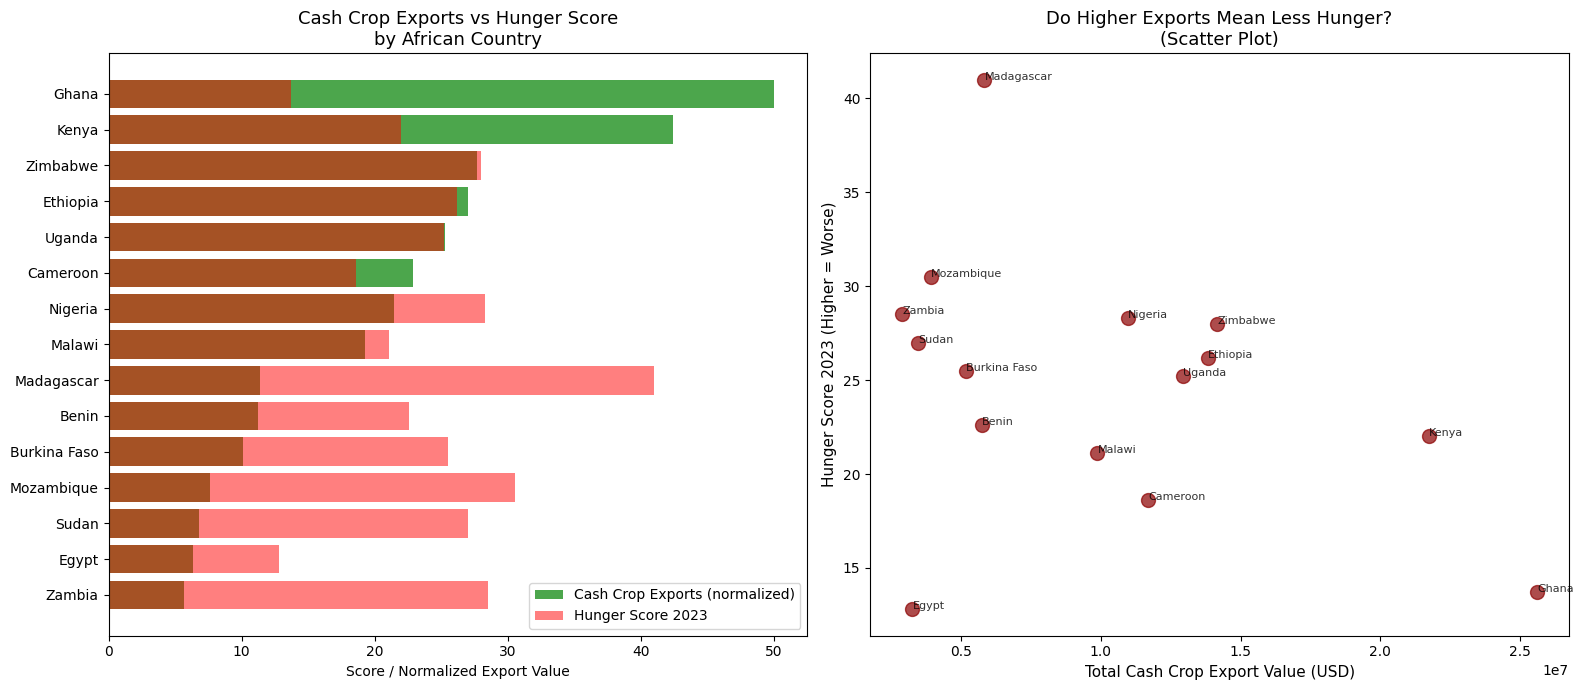

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 - Side by side comparison
x = range(len(comparison))
width = 0.35

# Normalize export values to same scale for visual comparison
comparison['Export_Normalized'] = (
    comparison['Total_Export_Value_USD'] /
    comparison['Total_Export_Value_USD'].max() * 50
)

axes[0].barh(comparison['Country'],
             comparison['Export_Normalized'],
             color='green', alpha=0.7, label='Cash Crop Exports (normalized)')
axes[0].barh(comparison['Country'],
             comparison['Hunger_Score_2023'],
             color='red', alpha=0.5, label='Hunger Score 2023')
axes[0].set_title('Cash Crop Exports vs Hunger Score\nby African Country', fontsize=13)
axes[0].set_xlabel('Score / Normalized Export Value')
axes[0].legend()
axes[0].invert_yaxis()

# Chart 2 - Scatter plot
axes[1].scatter(comparison['Total_Export_Value_USD'],
                comparison['Hunger_Score_2023'],
                color='darkred', s=100, alpha=0.7)

for i, row in comparison.iterrows():
    axes[1].annotate(row['Country'],
                    (row['Total_Export_Value_USD'], row['Hunger_Score_2023']),
                    fontsize=8, alpha=0.8)

axes[1].set_title('Do Higher Exports Mean Less Hunger?\n(Scatter Plot)', fontsize=13)
axes[1].set_xlabel('Total Cash Crop Export Value (USD)', fontsize=11)
axes[1].set_ylabel('Hunger Score 2023 (Higher = Worse)', fontsize=11)

plt.tight_layout()
plt.show()

In [16]:
# Get malnutrition deaths for African countries
africa_deaths_mal = africa_deaths[['Country/Territory', 'Year',
                                    'Protein-Energy Malnutrition',
                                    'Nutritional Deficiencies']].copy()

# Get average deaths per country across all years
avg_deaths = africa_deaths_mal.groupby('Country/Territory')[
    ['Protein-Energy Malnutrition', 'Nutritional Deficiencies']
].mean().reset_index()

avg_deaths.columns = ['Country', 'Avg_Malnutrition_Deaths', 'Avg_Nutritional_Deaths']
avg_deaths = avg_deaths.sort_values('Avg_Malnutrition_Deaths', ascending=False).head(15)

print("Top 15 African Countries by Average Malnutrition Deaths:")
print(avg_deaths)

Top 15 African Countries by Average Malnutrition Deaths:
                         Country  Avg_Malnutrition_Deaths  \
19                      Ethiopia             26324.100000   
13  Democratic Republic of Congo             13872.566667   
47                      Tanzania             10328.566667   
31                          Mali              9931.800000   
38                       Nigeria              9015.666667   
29                    Madagascar              8430.300000   
43                       Somalia              8341.166667   
1                         Angola              7662.100000   
35                    Mozambique              6298.166667   
50                        Uganda              6249.533333   
25                         Kenya              5588.400000   
45                   South Sudan              5450.866667   
4                   Burkina Faso              4506.466667   
9                           Chad              4074.600000   
37                         N

In [17]:
# Merge exports + hunger + deaths into one master table
master = pd.merge(comparison, avg_deaths, on='Country', how='inner')

print("MASTER TABLE — Exports vs Hunger vs Deaths:")
print(master[['Country', 'Total_Export_Value_USD',
              'Hunger_Score_2023',
              'Avg_Malnutrition_Deaths']].sort_values(
                  'Avg_Malnutrition_Deaths', ascending=False))

MASTER TABLE — Exports vs Hunger vs Deaths:
        Country  Total_Export_Value_USD  Hunger_Score_2023  \
1      Ethiopia              13833493.0               26.2   
3       Nigeria              10981250.0               28.3   
4    Madagascar               5839555.0               41.0   
6    Mozambique               3917491.0               30.5   
2        Uganda              12933293.0               25.2   
0         Kenya              21741665.0               22.0   
5  Burkina Faso               5180216.0               25.5   

   Avg_Malnutrition_Deaths  
1             26324.100000  
3              9015.666667  
4              8430.300000  
6              6298.166667  
2              6249.533333  
0              5588.400000  
5              4506.466667  


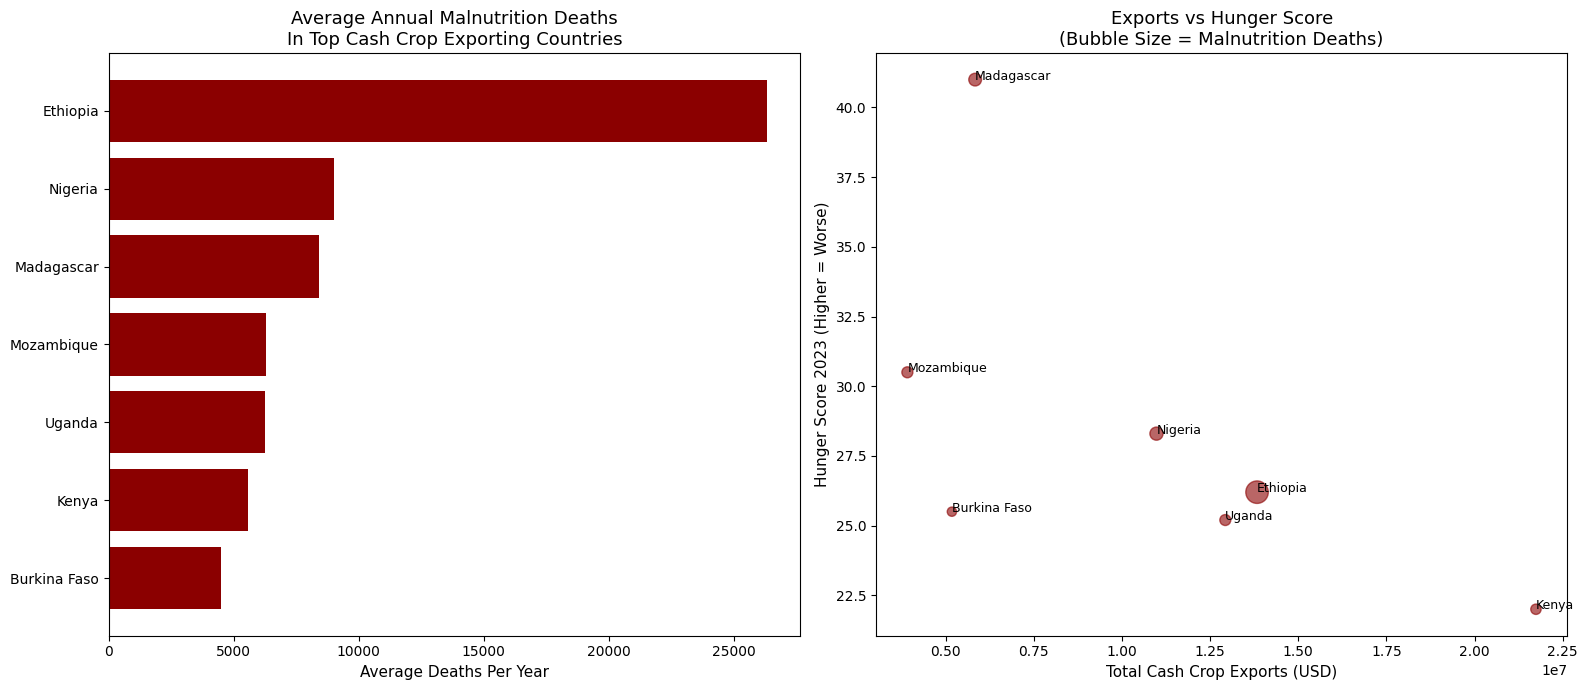

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1 - Malnutrition deaths by country
axes[0].barh(master.sort_values('Avg_Malnutrition_Deaths')['Country'],
             master.sort_values('Avg_Malnutrition_Deaths')['Avg_Malnutrition_Deaths'],
             color='darkred')
axes[0].set_title('Average Annual Malnutrition Deaths\nIn Top Cash Crop Exporting Countries', fontsize=13)
axes[0].set_xlabel('Average Deaths Per Year', fontsize=11)

# Chart 2 - Bubble chart: exports vs hunger, bubble size = deaths
bubble_size = master['Avg_Malnutrition_Deaths'] / 100

axes[1].scatter(master['Total_Export_Value_USD'],
                master['Hunger_Score_2023'],
                s=bubble_size,
                color='darkred', alpha=0.6)

for i, row in master.iterrows():
    axes[1].annotate(row['Country'],
                    (row['Total_Export_Value_USD'], row['Hunger_Score_2023']),
                    fontsize=9)

axes[1].set_title('Exports vs Hunger Score\n(Bubble Size = Malnutrition Deaths)', fontsize=13)
axes[1].set_xlabel('Total Cash Crop Exports (USD)', fontsize=11)
axes[1].set_ylabel('Hunger Score 2023 (Higher = Worse)', fontsize=11)

plt.tight_layout()
plt.show()

In [19]:
# Add GDP to the master table
africa_gdp_avg = africa_gdp.groupby(
    'Country Name')['GDP per capita'].mean().reset_index()
africa_gdp_avg.columns = ['Country', 'Avg_GDP']

master_full = pd.merge(master, africa_gdp_avg, on='Country', how='left')
print(master_full[['Country', 'Total_Export_Value_USD',
                   'Hunger_Score_2023', 'Avg_Malnutrition_Deaths',
                   'Avg_GDP']].sort_values('Avg_Malnutrition_Deaths',
                                           ascending=False))

        Country  Total_Export_Value_USD  Hunger_Score_2023  \
1      Ethiopia              13833493.0               26.2   
3       Nigeria              10981250.0               28.3   
4    Madagascar               5839555.0               41.0   
6    Mozambique               3917491.0               30.5   
2        Uganda              12933293.0               25.2   
0         Kenya              21741665.0               22.0   
5  Burkina Faso               5180216.0               25.5   

   Avg_Malnutrition_Deaths      Avg_GDP  
1             26324.100000   570.645542  
3              9015.666667  2576.602915  
4              8430.300000   454.083682  
6              6298.166667   559.850425  
2              6249.533333   843.481539  
0              5588.400000  1446.008987  
5              4506.466667   619.073503  


In [20]:
print("""
=== PROJECT FINDINGS: Cash Crops, Hunger & Death in Africa ===

1. Ethiopia is Africa's most alarming case — $13.8M in annual cash crop
   exports but 26,324 average malnutrition deaths per year and a GDP
   of just $570 per person.

2. Madagascar has the worst hunger score (41/100) with the lowest GDP
   ($454/person) — proving poverty drives hunger more than export volume.

3. Kenya exports the most ($21.7M) but has the highest GDP ($1,446)
   and lowest deaths (5,588) — showing export revenue CAN reduce hunger
   when the economy is stronger.

4. CONCLUSION: Cash crop exports alone don't cause hunger. The real
   crisis is that export revenue doesn't reach citizens in low-GDP
   nations — leaving families unable to afford food their own country
   is selling abroad.
""")


=== PROJECT FINDINGS: Cash Crops, Hunger & Death in Africa ===

1. Ethiopia is Africa's most alarming case — $13.8M in annual cash crop 
   exports but 26,324 average malnutrition deaths per year and a GDP 
   of just $570 per person.

2. Madagascar has the worst hunger score (41/100) with the lowest GDP 
   ($454/person) — proving poverty drives hunger more than export volume.

3. Kenya exports the most ($21.7M) but has the highest GDP ($1,446) 
   and lowest deaths (5,588) — showing export revenue CAN reduce hunger 
   when the economy is stronger.

4. CONCLUSION: Cash crop exports alone don't cause hunger. The real 
   crisis is that export revenue doesn't reach citizens in low-GDP 
   nations — leaving families unable to afford food their own country 
   is selling abroad.

